# MoE Routing Analysis

Runs post-adaptation routing analysis on held-out (val) users and visualises
what each expert has learned to specialise in.

**Pipeline:**
1. Load a trained MoE checkpoint + config
2. Build the val episodic dataloader (held-out users only)
3. For each episode: adapt on support → collect gate weights on query
4. Analyse and plot: gesture × expert, participant × expert, demographics × expert

**Key design choice:** analysis is run *post-adaptation* on *query samples only*.
This shows what the gate actually settles on for unseen users after a few support
shots — the scientifically interesting question, and the right thing to show reviewers.

## 0. Imports & path setup

In [1]:
import sys
import os
import json
import torch
import pickle
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import math

matplotlib.rcParams['figure.dpi'] = 120

PROJECT_ROOT = r"C:\Users\kdmen\Repos\pers-gest-cls\system"
sys.path.insert(0, PROJECT_ROOT)

from MOE.MOE_encoder import build_MOE_model
from MOE.MOE_analysis import RoutingCollector, RoutingAnalyzer, RoutingRecord
from MAML.mamlpp import mamlpp_adapt, _normalize_step_item, named_param_dict, FunctionalModel
from MAML.maml_data_pipeline import get_maml_dataloaders

print('Imports OK')
print(f'PyTorch: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')

Imports OK
PyTorch: 2.7.1+cu128
CUDA available: True


## 1. Load train/val PID split from JSON

Your config does not store `train_PIDs` / `val_PIDs` directly — they live in
`user_split_json_filepath`. We load that JSON here and pick the correct fold.

**DUMMY_VARIABLE:** set `FOLD_KEY` to the fold this model was trained on.

In [2]:
SPLIT_JSON_PATH = r"C:\Users\kdmen\Repos\pers-gest-cls\system\fixed_user_splits\4kfcv_splits_shared_test.json"

FOLD_KEY = 0

with open(SPLIT_JSON_PATH, 'r') as f:
    split_data = json.load(f)

#print(split_data)
#print(len(split_data))

fold       = split_data[FOLD_KEY]
TRAIN_PIDS = fold['train']   # adjust key name if your JSON uses different names
# NOTE: Here, since we are not doing training, only viz, we can just combine all our withheld users
VAL_PIDS   = fold['val'] + fold['test']

print(f'Train PIDs ({len(TRAIN_PIDS)}): {sorted(TRAIN_PIDS)}')
print(f'Val   PIDs ({len(VAL_PIDS)}):   {sorted(VAL_PIDS)}')
assert len(set(TRAIN_PIDS) & set(VAL_PIDS)) == 0, 'PID leakage between train and val!'

Train PIDs (24): ['P005', 'P010', 'P102', 'P103', 'P104', 'P106', 'P107', 'P108', 'P110', 'P111', 'P112', 'P114', 'P115', 'P116', 'P118', 'P119', 'P122', 'P124', 'P125', 'P126', 'P127', 'P128', 'P131', 'P132']
Val   PIDs (8):   ['P004', 'P006', 'P008', 'P011', 'P105', 'P109', 'P121', 'P123']


## 2. Config

In [3]:
config = {
    # ── Model ──────────────────────────────────────────────────────────────
    'model_type':                          'DeepCNNLSTM',
    'use_MOE':                             True,
    'MOE_placement':                       'encoder',
    'num_experts':                         24,
    'MOE_ctx_hidden_dim':                  32,
    'MOE_ctx_out_dim':                     64,
    'MOE_gate_temperature':                1.1879664247660187,
    'MOE_top_k':                           7,
    'top_k':                               7,      # used by _compute_aux_loss
    'MOE_dropout':                         0.022501513050004283,
    'MOE_expert_expand':                   1.0,
    'MOE_mlp_hidden_mult':                 1.0,
    'MOE_aux_coeff':                       0.08672942143224953,
    'apply_MOE_aux_loss_inner_outer':      'outer',
    'FILM_on_context_or_demo':             'context',
    'gate_type':                           'context_feature_demo',
    'expert_architecture':                 'MLP',
    'front_end_stride':                    0,
    'MOE_log_every':                       5,
    'MOE_plot_dir':                        None,

    # ── Data ───────────────────────────────────────────────────────────────
    'emg_in_ch':                           16,
    'imu_in_ch':                           72,
    'use_imu':                             True,
    'multimodal':                          True,
    'use_demographics':                    False,
    'use_film_x_demo':                     False,
    'demo_in_dim':                         12,
    'sequence_length':                     64,
    'augment':                             False,
    'feature_engr':                        None,
    'padding':                             0,

    # ── Architecture ───────────────────────────────────────────────────────
    'cnn_base_filters':                    64,
    'cnn_layers':                          3,
    'cnn_kernel':                          5,
    'cnn_filters':                         64,    # MetaCNNLSTM compat key
    'groupnorm_num_groups':                8,
    'lstm_hidden':                         64,
    'lstm_layers':                         3,
    'dropout':                             0.1,
    'bidirectional':                       True,
    'head_type':                           'mlp',
    'use_GlobalAvgPooling':                True,
    'use_batch_norm':                      False,

    # ── Meta-learning ──────────────────────────────────────────────────────
    'meta_learning':                       True,
    'n_way':                               3,
    'k_shot':                              1,
    'q_query':                             9,
    'num_classes':                         10,
    'pretrain_num_classes':                10,
    'available_gesture_classes':           [0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
    'maml_inner_steps':                    10,
    'maml_inner_steps_eval':               10,
    'maml_alpha_init':                     0.0009888781900907544,
    'maml_alpha_init_eval':                0.006717556958813548,
    'maml_use_lslr':                       True,
    'use_lslr_at_eval':                    False,
    'maml_opt_order':                      'first',
    'maml_first_order_to_second_order_epoch': 1000000,
    'use_maml_msl':                        'hybrid',
    'maml_msl_num_epochs':                 39,
    'meta_batchsize':                      24,
    'label_smooth':                        0.05,
    'ft_label_smooth':                     0.0,
    'enable_inner_loop_optimizable_bn_params': False,
    'track_gradient_alignment':            False,

    # ── Optimiser / scheduler ──────────────────────────────────────────────
    'optimizer':                           'adam',
    'learning_rate':                       0.00010093304999603776,
    'weight_decay':                        0.0008325426470137959,
    'gradient_clip_max_norm':              10.0,
    'lr_scheduler_factor':                 0.1,
    'lr_scheduler_patience':              6,
    'use_cosine_outer_lr':                 False,
    'use_earlystopping':                   True,
    'earlystopping_min_delta':             0.005,
    'earlystopping_patience':              8,

    # ── Pretrain ───────────────────────────────────────────────────────────
    'pretrain_approach':                   None,
    'pretrained_model_filename':           None,
    'pretrain_dir':                        'C:\\Users\\kdmen\\Repos\\pers-gest-cls\\hpo_best_models\\',

    # ── PIDs (loaded from JSON in cell 1) ──────────────────────────────────
    'train_PIDs':                          TRAIN_PIDS,
    'val_PIDs':                            VAL_PIDS,

    # ── Episode / dataloader ───────────────────────────────────────────────
    'maml_gesture_classes':                [0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
    # None instead of [1..10]: original values are 1-indexed rep numbers but
    # the dataloader expects 0-indexed trial positions. None = use all trials.
    'target_trial_indices':                None,
    'train_reps':                          [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'val_reps':                            [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'episodes_per_epoch_train':            250,
    'num_eval_episodes':                   100,
    'num_workers':                         0,     # must be 0 in notebooks
    'use_label_shuf_meta_aug':             False, # deterministic episodes for analysis
    'seed':                                42,
    'debug_one_episode':                   False,
    'debug_five_episodes':                 False,
    'debug_one_user_only':                 False,
    'debug_verbose':                       False,
    'subject_specific_model':              False,
    'NOTS':                                True,
    'ablation_id':                         'M0',

    # ── Paths ──────────────────────────────────────────────────────────────
    'dfs_load_path':                       'C:\\Users\\kdmen\\Repos\\pers-gest-cls\\dataset\\meta-learning-sup-que-ds\\',
    'user_split_json_filepath':            SPLIT_JSON_PATH,
    'models_save_dir':                     None,
    'results_save_dir':                    r'C:\Users\kdmen\Repos\pers-gest-cls\paper_figures',

    # ── Device ─────────────────────────────────────────────────────────────
    'device':                              'cuda' if torch.cuda.is_available() else 'cpu',

    # ── Routing analysis metadata ──────────────────────────────────────────
    # 12 entries — matches the 12 columns in the demo tensor after
    # pd.get_dummies(..., drop_first=True) drops: disability=ET, handedness=Left, gender=Man
    'demo_dim_labels': [
        'time_disabled', 'age', 'BMI', 'DASH_score',
        'disability_coding_MD', 'disability_coding_No_Disability',
        'disability_coding_PN', 'disability_coding_SCI', 'disability_coding_other',
        'handedness_Right',
        'gender_Non-binary', 'gender_Woman',
    ],
}

print(f"Device: {config['device']}")
print(f"Num experts: {config['num_experts']}  |  top_k: {config['MOE_top_k']}")
print(f"Val PIDs ({len(config['val_PIDs'])}): {sorted(config['val_PIDs'])}")
print(f"demo_dim_labels ({len(config['demo_dim_labels'])} entries): {config['demo_dim_labels']}")

Device: cuda
Num experts: 24  |  top_k: 7
Val PIDs (8): ['P004', 'P006', 'P008', 'P011', 'P105', 'P109', 'P121', 'P123']
demo_dim_labels (12 entries): ['time_disabled', 'age', 'BMI', 'DASH_score', 'disability_coding_MD', 'disability_coding_No_Disability', 'disability_coding_PN', 'disability_coding_SCI', 'disability_coding_other', 'handedness_Right', 'gender_Non-binary', 'gender_Woman']


## 3. Load data (val users only)

In [4]:
TENSOR_DICT_PATH = r"C:\Users\kdmen\Repos\pers-gest-cls\dataset\meta-learning-sup-que-ds\segfilt_rts_tensor_dict.pkl"

_, val_dl = get_maml_dataloaders(config, TENSOR_DICT_PATH)
print(f'Val dataloader: {len(val_dl)} episodes')

[get_maml_dataloaders] Train PIDs (24): ['P005', 'P010', 'P102', 'P103', 'P104', 'P106', 'P107', 'P108', 'P110', 'P111', 'P112', 'P114', 'P115', 'P116', 'P118', 'P119', 'P122', 'P124', 'P125', 'P126', 'P127', 'P128', 'P131', 'P132']
[get_maml_dataloaders] Val   PIDs (8):   ['P004', 'P006', 'P008', 'P011', 'P105', 'P109', 'P121', 'P123']
[get_maml_dataloaders] num_eval_episodes per val user: 100
[get_maml_dataloaders] Total val episodes in cache: 800
[get_maml_dataloaders] use_label_shuf_meta_aug: False
Val dataloader: 800 episodes


## 4. Load model checkpoint

In [5]:
# DUMMY_VARIABLE: path to your best model checkpoint
CHECKPOINT_PATH = r"C:\Users\kdmen\Repos\pers-gest-cls\hpo_best_models\M0_best.pt"

model = build_MOE_model(config)
model = model.to(config['device'])

from MAML.mamlpp import PerParamPerStepLSLR, named_param_dict

# Recreate _lslr before loading — it's monkey-patched at train time, not in __init__
if config["maml_use_lslr"]:
    temp_params = named_param_dict(model, require_grad_only=True)
    model._lslr = PerParamPerStepLSLR(
        named_params = temp_params.items(),
        inner_steps  = config["maml_inner_steps"],  # must match train-time value
        init_lr      = config["maml_alpha_init"],
        learnable    = True,
        device       = config["device"],
    ).to(config["device"])

ckpt = torch.load(CHECKPOINT_PATH, map_location=config["device"])
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

n_params = sum(p.numel() for p in model.parameters())
print(f"Model loaded: {config['model_type']} ({config['MOE_placement']} MoE) | {n_params:,} parameters")
print(f"Checkpoint epoch: {ckpt.get('epoch', 'unknown')}")

Model loaded: DeepCNNLSTM (encoder MoE) | 6,006,256 parameters
Checkpoint epoch: unknown


## 5. Sanity check: demo tensor dimension

Verifies the demo tensor in your data has exactly 12 columns (matching `demo_dim_labels`).
Also confirms `global_labels` are present for gesture-level analysis.
Fix any assertion failure before proceeding.

In [6]:
for batch in val_dl:
    demo_tensor = batch['query']['demo']
    print(f"query['demo'] shape   : {demo_tensor.shape}  -> {demo_tensor.shape[1]} demographic columns")
    print(f"demo_dim_labels count : {len(config['demo_dim_labels'])} entries")
    assert demo_tensor.shape[1] == len(config['demo_dim_labels']), (
        f"MISMATCH: demo tensor has {demo_tensor.shape[1]} cols but "
        f"demo_dim_labels has {len(config['demo_dim_labels'])} entries. "
        "Fix the label list before continuing."
    )
    print('CHECK demo dimension matches label list')

    assert 'global_labels' in batch['query'], \
        "'global_labels' missing from query batch — re-check your collate fn."
    print(f"CHECK global_labels present: {batch['query']['global_labels'].tolist()}")

    print(f"\nBatch keys — support : {list(batch['support'].keys())}")
    print(f"Batch keys — query   : {list(batch['query'].keys())}")
    print(f"Episode user_id      : {batch['user_id']}")
    break

query['demo'] shape   : torch.Size([27, 12])  -> 12 demographic columns
demo_dim_labels count : 12 entries
CHECK demo dimension matches label list
CHECK global_labels present: [1, 0, 4, 4, 1, 0, 4, 4, 4, 1, 4, 1, 1, 0, 1, 0, 0, 4, 1, 4, 1, 0, 0, 1, 4, 0, 0]

Batch keys — support : ['emg', 'imu', 'demo', 'labels', 'global_labels']
Batch keys — query   : ['emg', 'imu', 'demo', 'labels', 'global_labels']
Episode user_id      : P011


> NOTE: global_labels_present only shows 3 different labels! But that is because within an episode, we are doing 1-shot 3-way episodic dataloaders and there are by definition only 3 classes per episode. The code above is checking per episode not globally (since the info the model/router will see is also per episode, not global).

## 6. Collect routing data

For each episode in the val loader:
- **Adapts** on the support set (inner loop, `create_graph=False` — no meta-gradient, cheap)
- **Collects** gate weights on the query set (samples the model never adapted to)

This is the correct setup for a NeurIPS figure: post-adaptation, query-only, held-out users.

In [7]:
num_experts = config['num_experts']
collector = RoutingCollector(
    num_experts = num_experts,
    model_name  = config['model_type'],
)

device     = config['device']
multimodal = bool(config.get('multimodal', True))
n_episodes = 0
n_skipped  = 0

model.eval()

for step_item in val_dl:
    episodes = _normalize_step_item(step_item)
    for episode in episodes:
        support_batch = episode['support']
        query_batch   = episode['query']

        # ── PID extraction ─────────────────────────────────────────────────
        user_id = episode['user_id']
        if isinstance(user_id, (list, tuple)):
            episode_pids = [str(p) for p in user_id]
        else:
            episode_pids = str(user_id)  # resolved to list once we know batch size

        # ── Inner-loop adaptation on support (no meta-gradient needed) ──────
        theta_prime = mamlpp_adapt(model, config, support_batch, use_lslr_at_eval=False)
        f_q = FunctionalModel(model, theta_prime)

        # ── Forward on query with routing ───────────────────────────────────
        qemg    = query_batch['emg'].to(device)
        qlabels = query_batch['labels'].to(device)
        qimu    = query_batch.get('imu')
        if qimu is not None and multimodal:
            qimu = qimu.to(device)
        else:
            qimu = None

        if isinstance(episode_pids, str):
            episode_pids = [episode_pids] * qemg.size(0)

        with torch.no_grad():
            out = f_q(qemg, qimu, return_routing=True)

        if not (isinstance(out, tuple) and len(out) == 2 and isinstance(out[1], dict)):
            n_skipped += 1
            continue

        _, routing_info = out
        gate_w = routing_info.get('gate_weights')
        if gate_w is None:
            n_skipped += 1
            continue

        # NOTE: collate fn uses key 'demo', not 'demographics'
        demo = query_batch.get('demo')

        # Use global gesture IDs (dataset-level 0..9), not local episode labels (0..n_way-1)
        gesture_ids = query_batch.get('global_labels', qlabels).cpu()

        collector.add(
            gate_weights   = gate_w.cpu(),
            gesture_labels = gesture_ids,
            pids           = episode_pids,
            demographics   = demo.cpu() if demo is not None else None,
        )
        n_episodes += 1

    model.eval()  # mamlpp_adapt sets model.train(); restore after each episode

print(f'Collected {n_episodes} episodes, skipped {n_skipped}')
record = collector.finalize()
print(f'Total query samples collected : {record.gate_weights.shape[0]}')
print(f'Gate weights shape            : {record.gate_weights.shape}  (N x E)')
print(f'Demographics collected        : {record.demographics is not None}')
if record.demographics is not None:
    print(f'Demographics shape            : {record.demographics.shape}  (N x D)')

Collected 800 episodes, skipped 0
Total query samples collected : 21600
Gate weights shape            : torch.Size([21600, 24])  (N x E)
Demographics collected        : True
Demographics shape            : torch.Size([21600, 12])  (N x D)


## 7. Run analysis (prints summary to stdout)

In [8]:
analyzer = RoutingAnalyzer(record)
report   = analyzer.full_report(
    print_report    = True,
    demo_dim_labels = config['demo_dim_labels'],
)
E = analyzer.E


  MoE Routing Analysis — DeepCNNLSTM
  N=21600  E=24

[Entropy]
  Mean (normalised 0→sharp, 1→flat): 0.6102
  Mean (nats):                        1.9392
  Std  (nats):                        0.0071

[Load Balance]  (ideal = 0.042)
  Hard imbalance ratio (max/min dom freq): 1617.25x
  Soft imbalance ratio (max/min mean wgt): 3.72x
    Expert 0: dom_freq=0.013  mean_wgt=0.040
    Expert 1: dom_freq=0.081  mean_wgt=0.060
    Expert 2: dom_freq=0.060  mean_wgt=0.040
    Expert 3: dom_freq=0.036  mean_wgt=0.033
    Expert 4: dom_freq=0.047  mean_wgt=0.044
    Expert 5: dom_freq=0.015  mean_wgt=0.036
    Expert 6: dom_freq=0.055  mean_wgt=0.054
    Expert 7: dom_freq=0.002  mean_wgt=0.026
    Expert 8: dom_freq=0.299  mean_wgt=0.092
    Expert 9: dom_freq=0.104  mean_wgt=0.043
    Expert 10: dom_freq=0.004  mean_wgt=0.036
    Expert 11: dom_freq=0.002  mean_wgt=0.025
    Expert 12: dom_freq=0.000  mean_wgt=0.043
    Expert 13: dom_freq=0.001  mean_wgt=0.038
    Expert 14: dom_freq=0.073  me

## 8. Figures

Each cell is independent — re-run any one without re-collecting data.

**Note on figure size:** E=24 experts means wide heatmaps. Cell annotations are
omitted on the wide figures for readability — use the colorbar instead.

### 8a. Expert load balance
Are samples distributed evenly across experts?
- **Soft** = mean gate weight (routing contribution)
- **Hard** = fraction of samples for which each expert has the highest weight

With top_k=7/24, expect ~7/24 ≈ 0.29 ideal hard fraction per active expert.

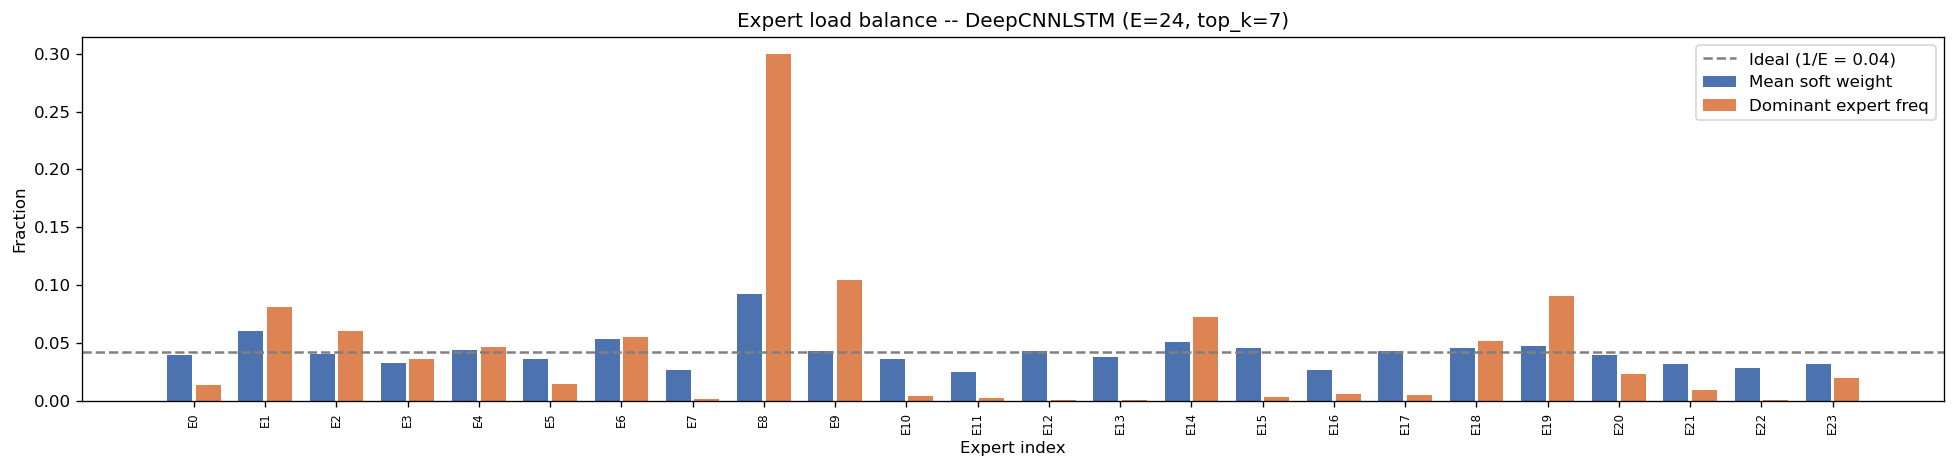

Hard imbalance ratio (max/min dom freq): 1617.25x
Soft imbalance ratio (max/min mean wgt): 3.72x


In [9]:
lb = analyzer.load_balance()

fig, ax = plt.subplots(figsize=(max(8, E * 0.6 + 2), 4))
x = np.arange(E)
ax.bar(x - 0.2, lb['expert_soft_fraction'], 0.35, label='Mean soft weight',    color='#4C72B0')
ax.bar(x + 0.2, lb['expert_hard_fraction'], 0.35, label='Dominant expert freq', color='#DD8452')
ax.axhline(lb['ideal_fraction'], color='gray', linestyle='--',
           label=f"Ideal (1/E = {lb['ideal_fraction']:.2f})")
ax.set_xlabel('Expert index')
ax.set_ylabel('Fraction')
ax.set_title(f"Expert load balance -- {record.model_name} (E={E}, top_k={config['MOE_top_k']})")
ax.set_xticks(x)
ax.set_xticklabels([f'E{i}' for i in range(E)], rotation=90, fontsize=7)
ax.legend()
fig.tight_layout()
plt.show()

print(f"Hard imbalance ratio (max/min dom freq): {lb['hard_imbalance_ratio']:.2f}x")
print(f"Soft imbalance ratio (max/min mean wgt): {lb['soft_imbalance_ratio']:.2f}x")

### 8b. Gesture x Expert heatmap
- Y-axis: gesture class (global dataset ID 0-9)
- X-axis: expert (E0-E23)
- Color: mean gate weight assigned to that expert for all query samples of that gesture

**What to look for:** column-wise structure — certain experts consistently activated
for certain gestures indicates gesture-level specialisation.

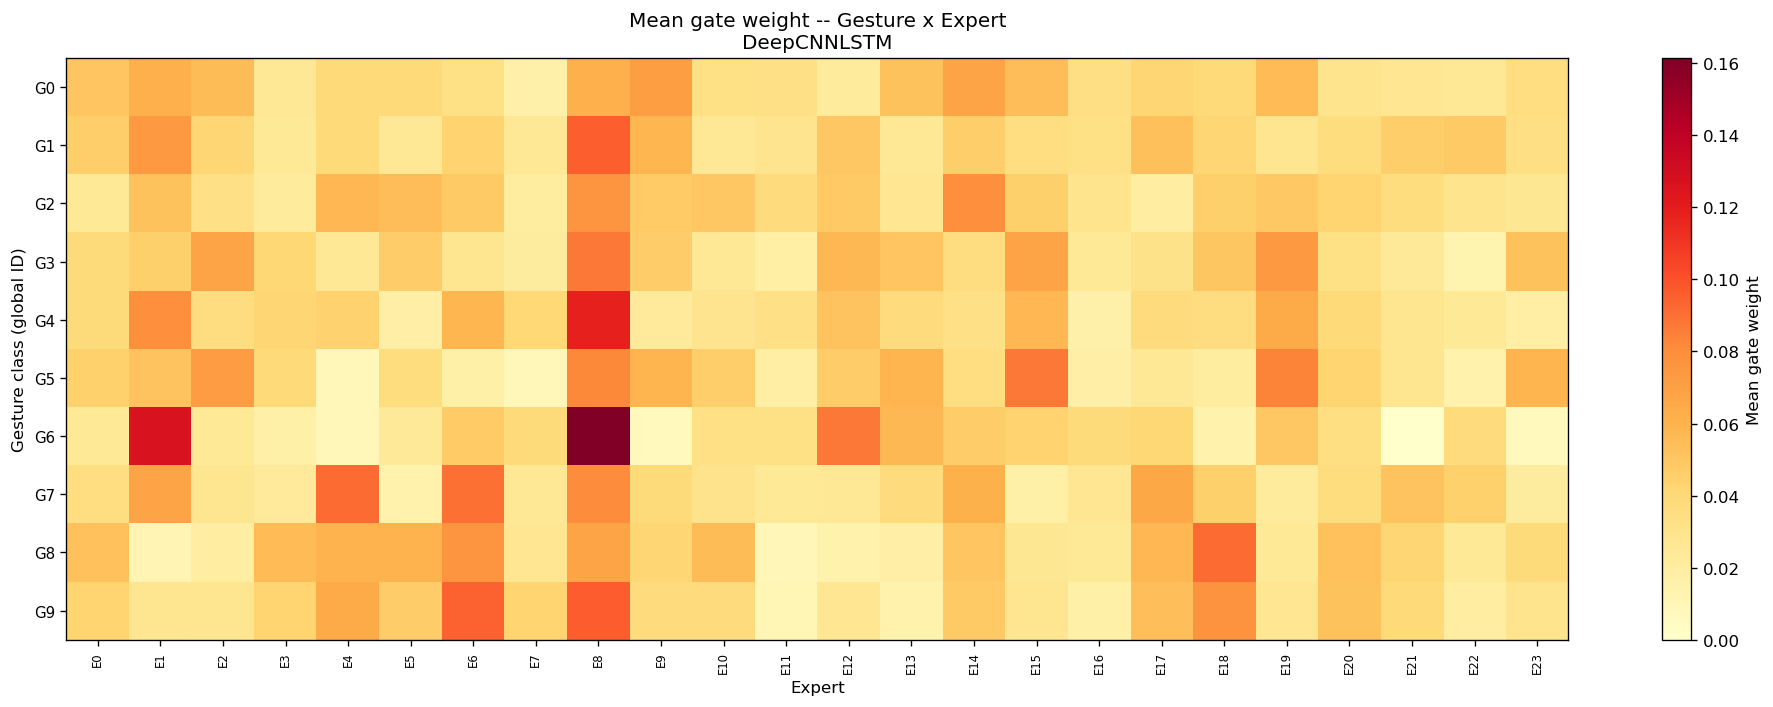

In [10]:
rg  = analyzer.routing_by_gesture()
mat = np.array(rg['mean_weight_matrix'])  # (G, E)
G   = len(rg['gesture_ids'])

fig, ax = plt.subplots(figsize=(max(8, E * 0.6 + 2), max(4, G * 0.5 + 1)))
im = ax.imshow(mat, aspect='auto', vmin=0, cmap='YlOrRd')
ax.set_xticks(range(E))
ax.set_xticklabels([f'E{i}' for i in range(E)], rotation=90, fontsize=7)
ax.set_yticks(range(G))
ax.set_yticklabels([f'G{g}' for g in rg['gesture_ids']], fontsize=9)
ax.set_xlabel('Expert')
ax.set_ylabel('Gesture class (global ID)')
ax.set_title(f'Mean gate weight -- Gesture x Expert\n{record.model_name}')
plt.colorbar(im, ax=ax, label='Mean gate weight')
fig.tight_layout()
plt.show()

### 8c. Participant x Expert heatmap
- Y-axis: participant ID
- X-axis: expert
- Color: mean gate weight across all query samples for that participant

**What to look for:** row-wise structure — if each participant consistently routes
to a subset of experts, the gate is picking up on inter-subject variability.

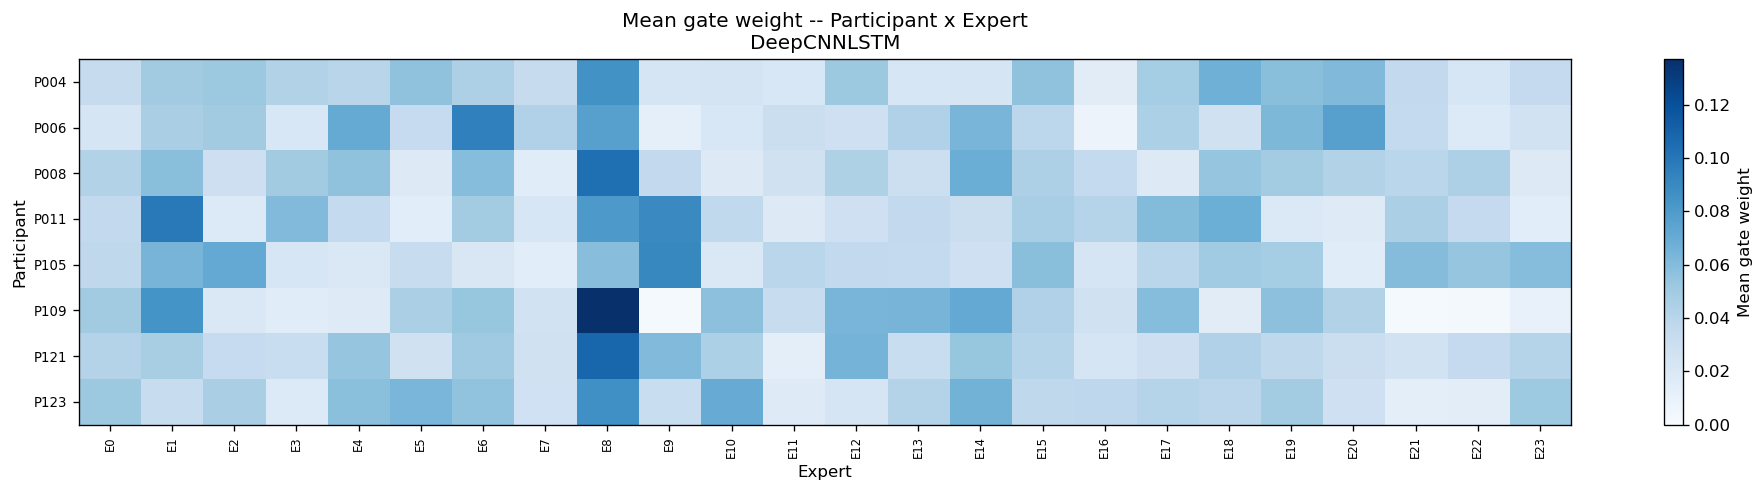

In [11]:
rp  = analyzer.routing_by_pid()
mat = np.array(rp['mean_weight_matrix'])  # (P, E)
P   = len(rp['pid_list'])

fig, ax = plt.subplots(figsize=(max(8, E * 0.6 + 2), max(4, P * 0.4 + 1)))
im = ax.imshow(mat, aspect='auto', vmin=0, cmap='Blues')
ax.set_xticks(range(E))
ax.set_xticklabels([f'E{i}' for i in range(E)], rotation=90, fontsize=7)
ax.set_yticks(range(P))
ax.set_yticklabels(rp['pid_list'], fontsize=8)
ax.set_xlabel('Expert')
ax.set_ylabel('Participant')
ax.set_title(f'Mean gate weight -- Participant x Expert\n{record.model_name}')
plt.colorbar(im, ax=ax, label='Mean gate weight')
fig.tight_layout()
plt.show()

### 8d. Demographics x Expert correlation
- Y-axis: demographic feature
- X-axis: expert
- Color: Pearson r (red = positive correlation, blue = negative)

**What to look for:** strong colors for disability coding rows — if `disability_coding_No_Disability`
anti-correlates with the same expert that `disability_coding_MD` positively correlates with,
that expert is specialising by disability status. Strongest scientific claim for the paper.

Reference categories (dropped by get_dummies, implicit baseline):
- Disability: **ET** | Handedness: **Left** | Gender: **Man**

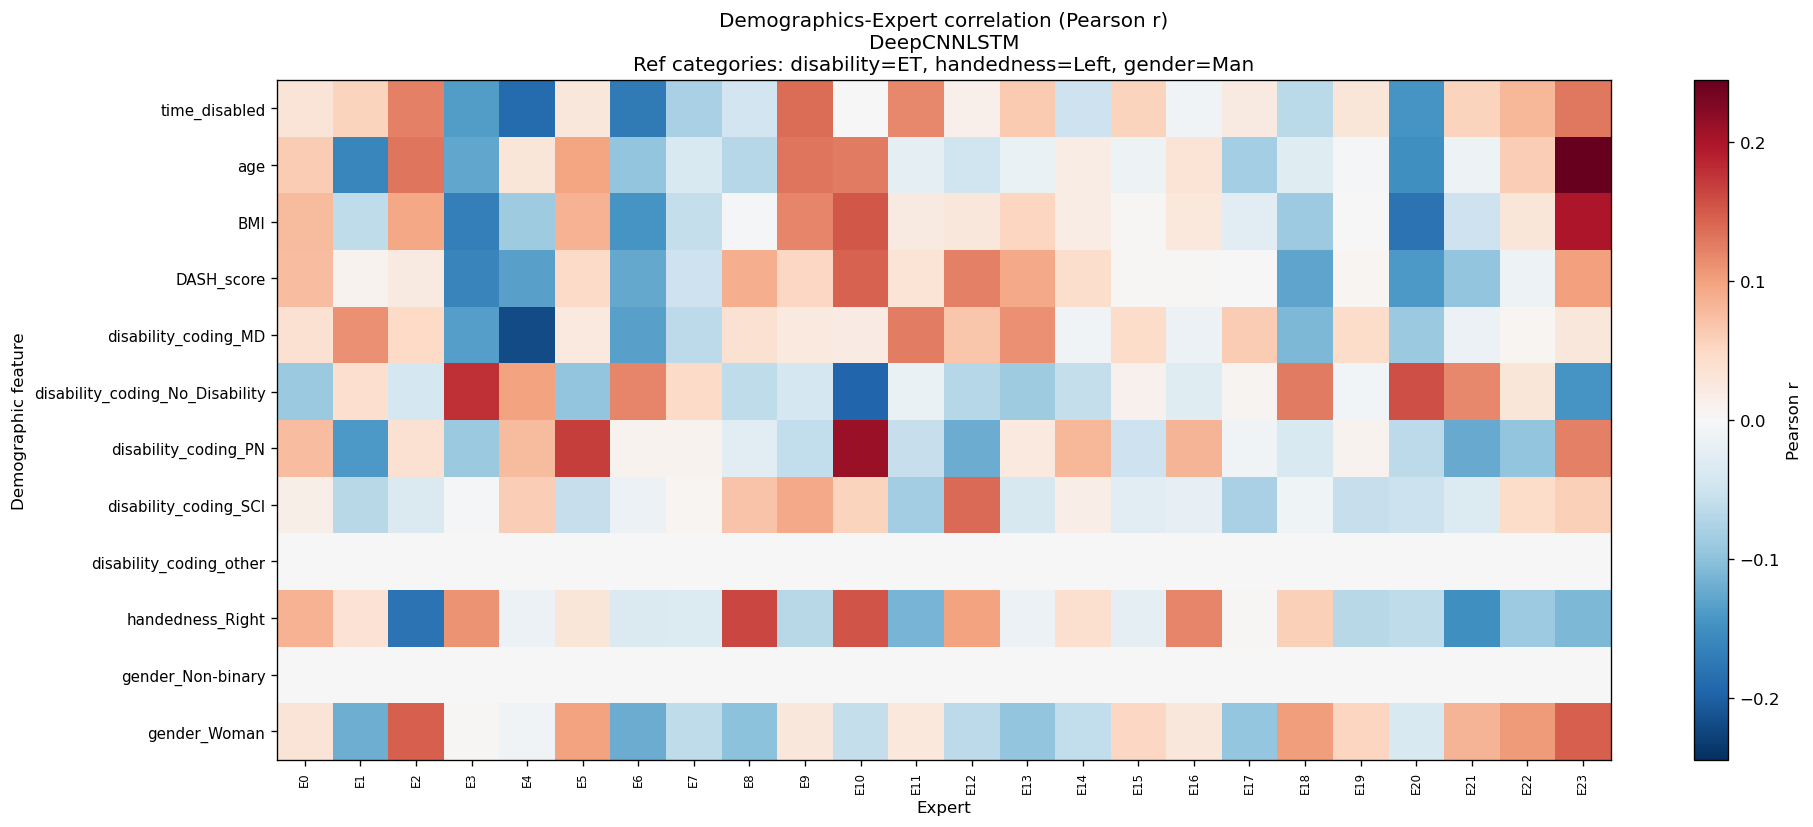


Strongest correlations (|r| > 0.15):
  time_disabled                                 <-> E04: r = -0.189
  time_disabled                                 <-> E06: r = -0.172
  age                                           <-> E01: r = -0.159
  age                                           <-> E23: r = +0.245
  BMI                                           <-> E03: r = -0.168
  BMI                                           <-> E10: r = +0.153
  BMI                                           <-> E20: r = -0.180
  BMI                                           <-> E23: r = +0.197
  DASH_score                                    <-> E03: r = -0.162
  disability_coding_MD                          <-> E04: r = -0.218
  disability_coding_No_Disability               <-> E03: r = +0.179
  disability_coding_No_Disability               <-> E10: r = -0.194
  disability_coding_No_Disability               <-> E20: r = +0.157
  disability_coding_PN                          <-> E05: r = +0.170
  disabili

In [12]:
if record.demographics is None:
    print("No demographics collected -- check that 'demo' key exists in query_batch (not 'demographics').")
else:
    rd   = analyzer.routing_by_demographics(demo_dim_labels=config['demo_dim_labels'])
    mat  = np.array(rd['correlation_matrix'])  # (D, E)
    D    = mat.shape[0]
    vlim = max(abs(mat).max(), 0.1)

    fig, ax = plt.subplots(figsize=(max(8, E * 0.6 + 2), max(4, D * 0.5 + 1)))
    im = ax.imshow(mat, aspect='auto', vmin=-vlim, vmax=vlim, cmap='RdBu_r')
    ax.set_xticks(range(E))
    ax.set_xticklabels([f'E{i}' for i in range(E)], rotation=90, fontsize=7)
    ax.set_yticks(range(D))
    ax.set_yticklabels(rd['demo_dim_labels'], fontsize=9)
    ax.set_xlabel('Expert')
    ax.set_ylabel('Demographic feature')
    ax.set_title(
        f'Demographics-Expert correlation (Pearson r)\n{record.model_name}\n'
        'Ref categories: disability=ET, handedness=Left, gender=Man'
    )
    plt.colorbar(im, ax=ax, label='Pearson r')
    fig.tight_layout()
    plt.show()

    print('\nStrongest correlations (|r| > 0.15):')
    found_any = False
    for d_idx, label in enumerate(rd['demo_dim_labels']):
        for e_idx in range(E):
            r = mat[d_idx, e_idx]
            if abs(r) > 0.15:
                print(f'  {label:45s} <-> E{e_idx:02d}: r = {r:+.3f}')
                found_any = True
    if not found_any:
        print('  None above 0.15 threshold -- try lowering to 0.10 if the plot shows structure.')

Dropping constant/absent features (no users): ['Essential Tremors', 'Other', 'Non-binary']
Keeping 12 features: ['Time Disabled', 'Age', 'BMI', 'DASH Score', 'Muscular Dystrophy', 'None', 'Peripheral Neuropathy', 'Spinal Cord Injury', 'Left', 'Right', 'Male', 'Female']


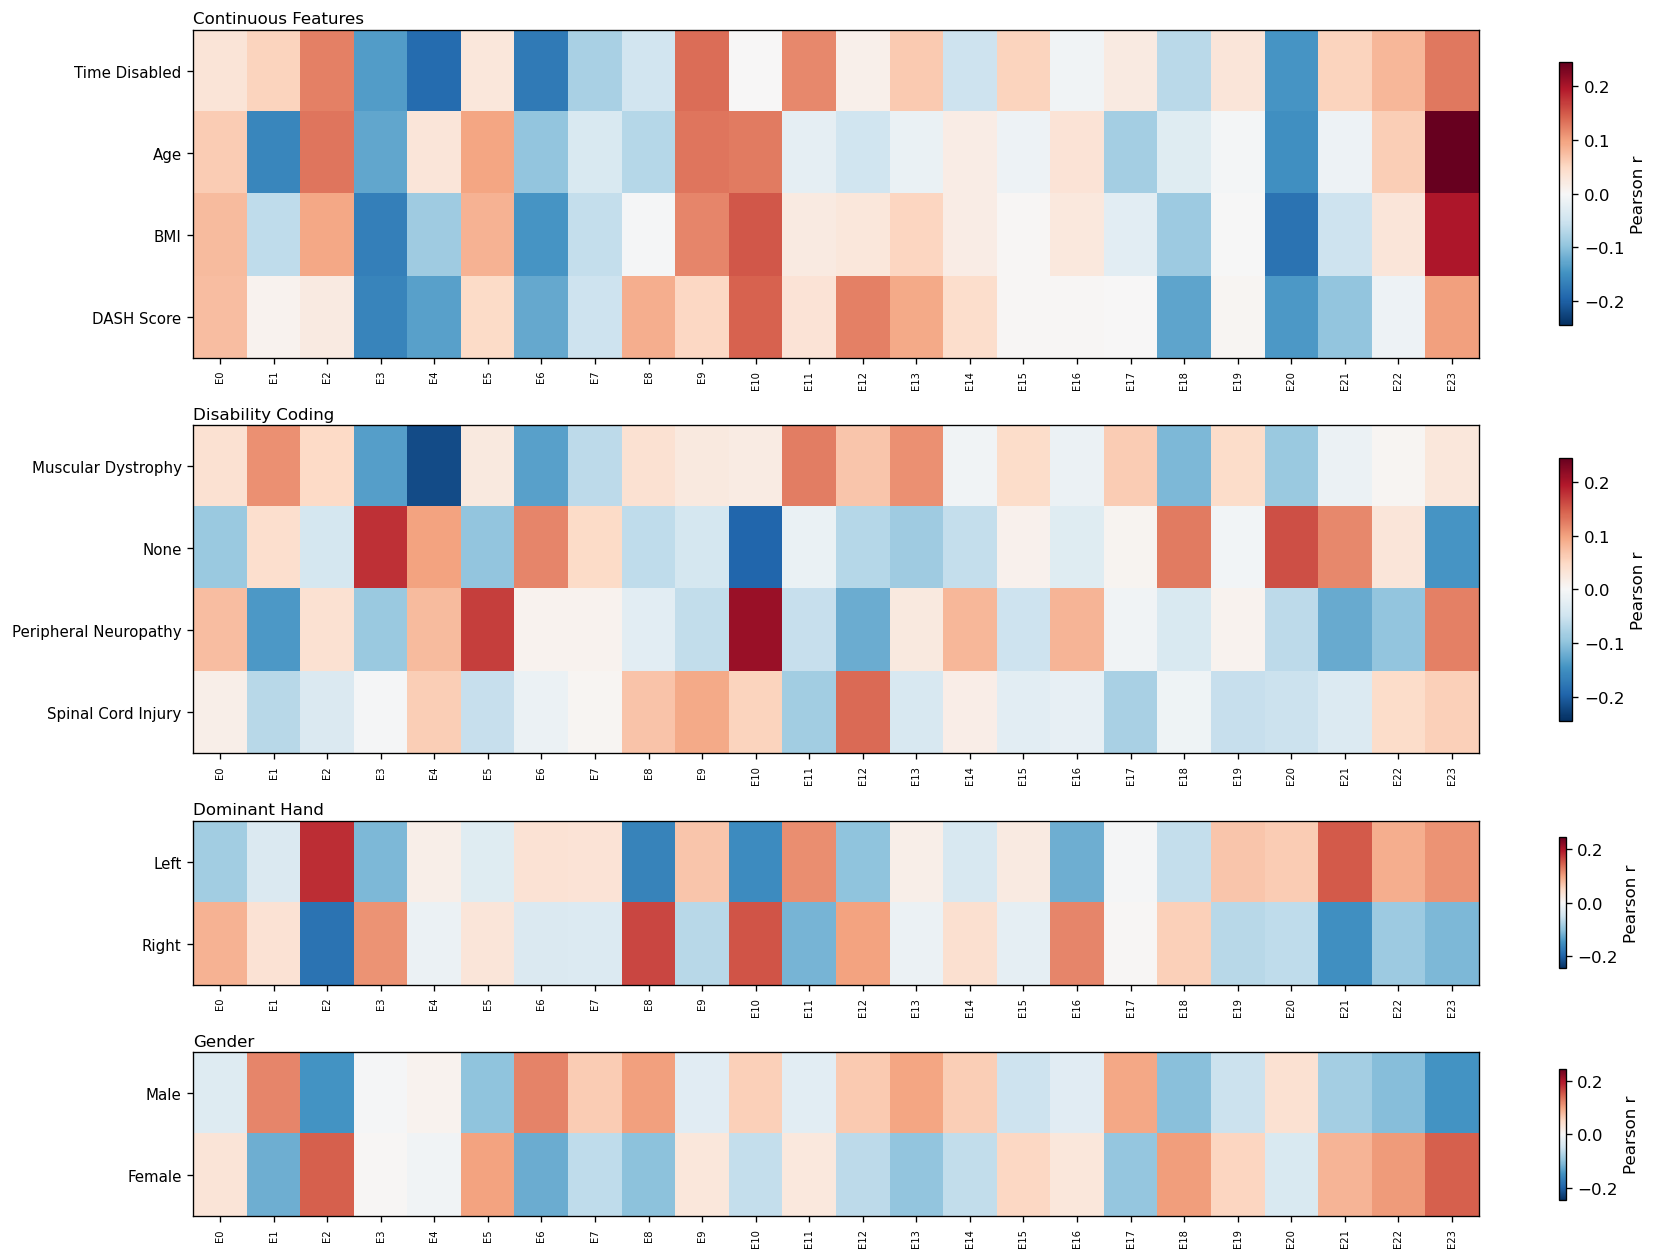


Continuous Features:
  Time Disabled                       <-> E04: r = -0.189
  Time Disabled                       <-> E06: r = -0.172
  Age                                 <-> E01: r = -0.159
  Age                                 <-> E23: r = +0.245
  BMI                                 <-> E03: r = -0.168
  BMI                                 <-> E10: r = +0.153
  BMI                                 <-> E20: r = -0.180
  BMI                                 <-> E23: r = +0.197
  DASH Score                          <-> E03: r = -0.162

Disability Coding:
  Muscular Dystrophy                  <-> E04: r = -0.218
  None                                <-> E03: r = +0.179
  None                                <-> E10: r = -0.194
  None                                <-> E20: r = +0.157
  Peripheral Neuropathy               <-> E05: r = +0.170
  Peripheral Neuropathy               <-> E10: r = +0.212

Dominant Hand:
  Left                                <-> E02: r = +0.180
  Left        

In [21]:
# ── 8d. Demographics × Expert correlation — grouped subpanels ─────────────────

if record.demographics is None:
    print("No demographics collected — check 'demo' key in query_batch.")
else:
    demo = record.demographics.float()   # (N, 12)
    gw   = record.gate_weights.float()   # (N, E)

    # ── Reconstruct dropped reference columns ────────────────────────────────
    disability_cols  = demo[:, 4:9]
    disability_ET    = 1.0 - disability_cols.sum(dim=1, keepdim=True)
    handedness_Left  = 1.0 - demo[:, 9:10]
    gender_Man       = 1.0 - demo[:, 10:12].sum(dim=1, keepdim=True)

    demo_aug = torch.cat([
        demo[:, :4],
        disability_ET, demo[:, 4:9],
        handedness_Left, demo[:, 9:10],
        gender_Man, demo[:, 10:12],
    ], dim=1)   # (N, 15)

    #all_labels = [
    #    "time_disabled", "age", "BMI", "DASH_score",
    #    "disability_ET", "disability_MD", "disability_No_Disability",
    #    "disability_PN", "disability_SCI", "disability_other",
    #    "handedness_Left", "handedness_Right",
    #    "gender_Man", "gender_Non-binary", "gender_Woman",
    #]
    all_labels = [
        "Time Disabled", "Age", "BMI", "DASH Score",
        "Essential Tremors", "Muscular Dystrophy", "None", "Peripheral Neuropathy", "Spinal Cord Injury", "Other",
        "Left", "Right",
        "Male", "Non-binary", "Female",
    ]

    # ── Drop rows where the feature is constant across all samples ───────────
    # A constant feature (all users the same value) has zero variance and will
    # produce r=0 for every expert — it carries no information. We detect this
    # by checking whether the column has any meaningful variation: if the sum of
    # absolute values across all rows is below a threshold, the column is flat.
    PRESENCE_THRESHOLD = 0.75   # sum(|col|) must exceed this to be kept
    keep_mask = demo_aug.abs().sum(dim=0) > PRESENCE_THRESHOLD   # (15,)
    demo_aug_filtered = demo_aug[:, keep_mask]
    labels_filtered   = [l for l, k in zip(all_labels, keep_mask.tolist()) if k]

    dropped = [l for l, k in zip(all_labels, keep_mask.tolist()) if not k]
    if dropped:
        print(f"Dropping constant/absent features (no users): {dropped}")
    print(f"Keeping {len(labels_filtered)} features: {labels_filtered}")

    # ── Compute correlation matrix ───────────────────────────────────────────
    def pearson_matrix(x: torch.Tensor, y: torch.Tensor) -> np.ndarray:
        D, Ey = x.shape[1], y.shape[1]
        corr  = np.zeros((D, Ey))
        xn, yn = x.numpy(), y.numpy()
        for d in range(D):
            xc = xn[:, d]
            for e in range(Ey):
                yc = yn[:, e]
                if xc.std() < 1e-8 or yc.std() < 1e-8:
                    corr[d, e] = 0.0
                else:
                    corr[d, e] = float(np.corrcoef(xc, yc)[0, 1])
        return corr
    def mean_gate_per_group(demo_col: torch.Tensor, gw: torch.Tensor) -> dict:
        # NOTE: Shapes here dont work...
        """
        For a binary column (0/1), returns mean gate weight per expert
        for the group where col=1 vs col=0.
        demo_col : (N,)
        gw       : (N, E)
        returns  : {"group_1": (E,), "group_0": (E,)}
        """
        mask1 = demo_col > 0.5
        mask0 = ~mask1
        return {
            "group_1": gw[mask1].mean(dim=0).numpy() if mask1.any() else np.zeros(gw.shape[1]),
            "group_0": gw[mask0].mean(dim=0).numpy() if mask0.any() else np.zeros(gw.shape[1]),
        }

    full_corr = pearson_matrix(demo_aug_filtered, gw)   # (D_kept, E)

    # ── Build groups from surviving rows ─────────────────────────────────────
    # Each group definition references labels; we only include rows that survived
    # the presence filter above.
    group_defs = [
        {"title": "Continuous Features",
         "labels": ["Time Disabled", "Age", "BMI", "DASH Score"]},
        {"title": "Disability Coding",
         "labels": ["Essential Tremors", "Muscular Dystrophy", "None",
                    "Peripheral Neuropathy", "Spinal Cord Injury", "Other"]},
        {"title": "Dominant Hand",
         "labels": ["Left", "Right"]},
        {"title": "Gender",
         "labels": ["Male", "Non-binary", "Female"]},
    ]

    # Filter each group to only rows that survived, and drop empty groups
    groups = []
    for gdef in group_defs:
        rows = [(labels_filtered.index(l), l)
                for l in gdef["labels"] if l in labels_filtered]
        if rows:
            groups.append({"title": gdef["title"], "rows": rows})

    # ── Global colorbar scale — same across all subplots ────────────────────
    vlim = max(abs(full_corr).max(), 0.05)

    # ── Plot ─────────────────────────────────────────────────────────────────
    fig_w    = max(10, E * 0.55 + 2)
    heights  = [max(2, len(g["rows"])) for g in groups]
    fig, axes = plt.subplots(
        len(groups), 1,
        figsize=(fig_w, sum(r * 0.55 + 1.0 for r in heights)),
        gridspec_kw={"height_ratios": heights},
    )
    if len(groups) == 1:
        axes = [axes]

    for ax, grp in zip(axes, groups):
        row_indices = [r[0] for r in grp["rows"]]
        row_labels  = [r[1] for r in grp["rows"]]
        sub_corr    = full_corr[row_indices, :]

        im = ax.imshow(sub_corr, aspect="auto",
                       vmin=-vlim, vmax=vlim, cmap="RdBu_r")
        ax.set_xticks(range(E))
        ax.set_xticklabels([f"E{i}" for i in range(E)], rotation=90, fontsize=6)
        ax.set_yticks(range(len(row_labels)))
        ax.set_yticklabels(row_labels, fontsize=9)
        ax.set_title(grp["title"], fontsize=10, loc="left", pad=4)
        plt.colorbar(im, ax=ax, label="Pearson r", shrink=0.8)

    #fig.suptitle(
    #    f"Demographics–Expert Correlation (Pearson r)\n"
    #    f"{record.model_name}  |  N_users={len(set(record.pids))}  |  N_samples={len(record.pids)}\n"
    #    "Colorbar scale is shared across all subplots  |  "
    #    "⚠ N_eff = number of unique users — treat as exploratory",
    #    fontsize=9, y=1.01,
    #)
    fig.tight_layout()
    plt.show()

    # ── Print strongest correlations ─────────────────────────────────────────
    THRESHOLD = 0.15
    for grp in groups:
        print(f"\n{grp['title']}:")
        found = False
        for row_idx, label in grp["rows"]:
            for e_idx in range(E):
                r = full_corr[row_idx, e_idx]
                if abs(r) > THRESHOLD:
                    print(f"  {label:35s} <-> E{e_idx:02d}: r = {r:+.3f}")
                    found = True
        if not found:
            print(f"  (no correlations above |r| = {THRESHOLD})")

top-k confirmed: each sample selects 7 experts
Dropped absent features: ['Essential Tremors', 'Other', 'Non-binary']
Kept 12 features: ['Time Disabled', 'Age', 'BMI', 'DASH Score', 'Muscular Dystrophy', 'None', 'Peripheral Neuropathy', 'Spinal Cord Injury', 'Left', 'Right', 'Male', 'Female']


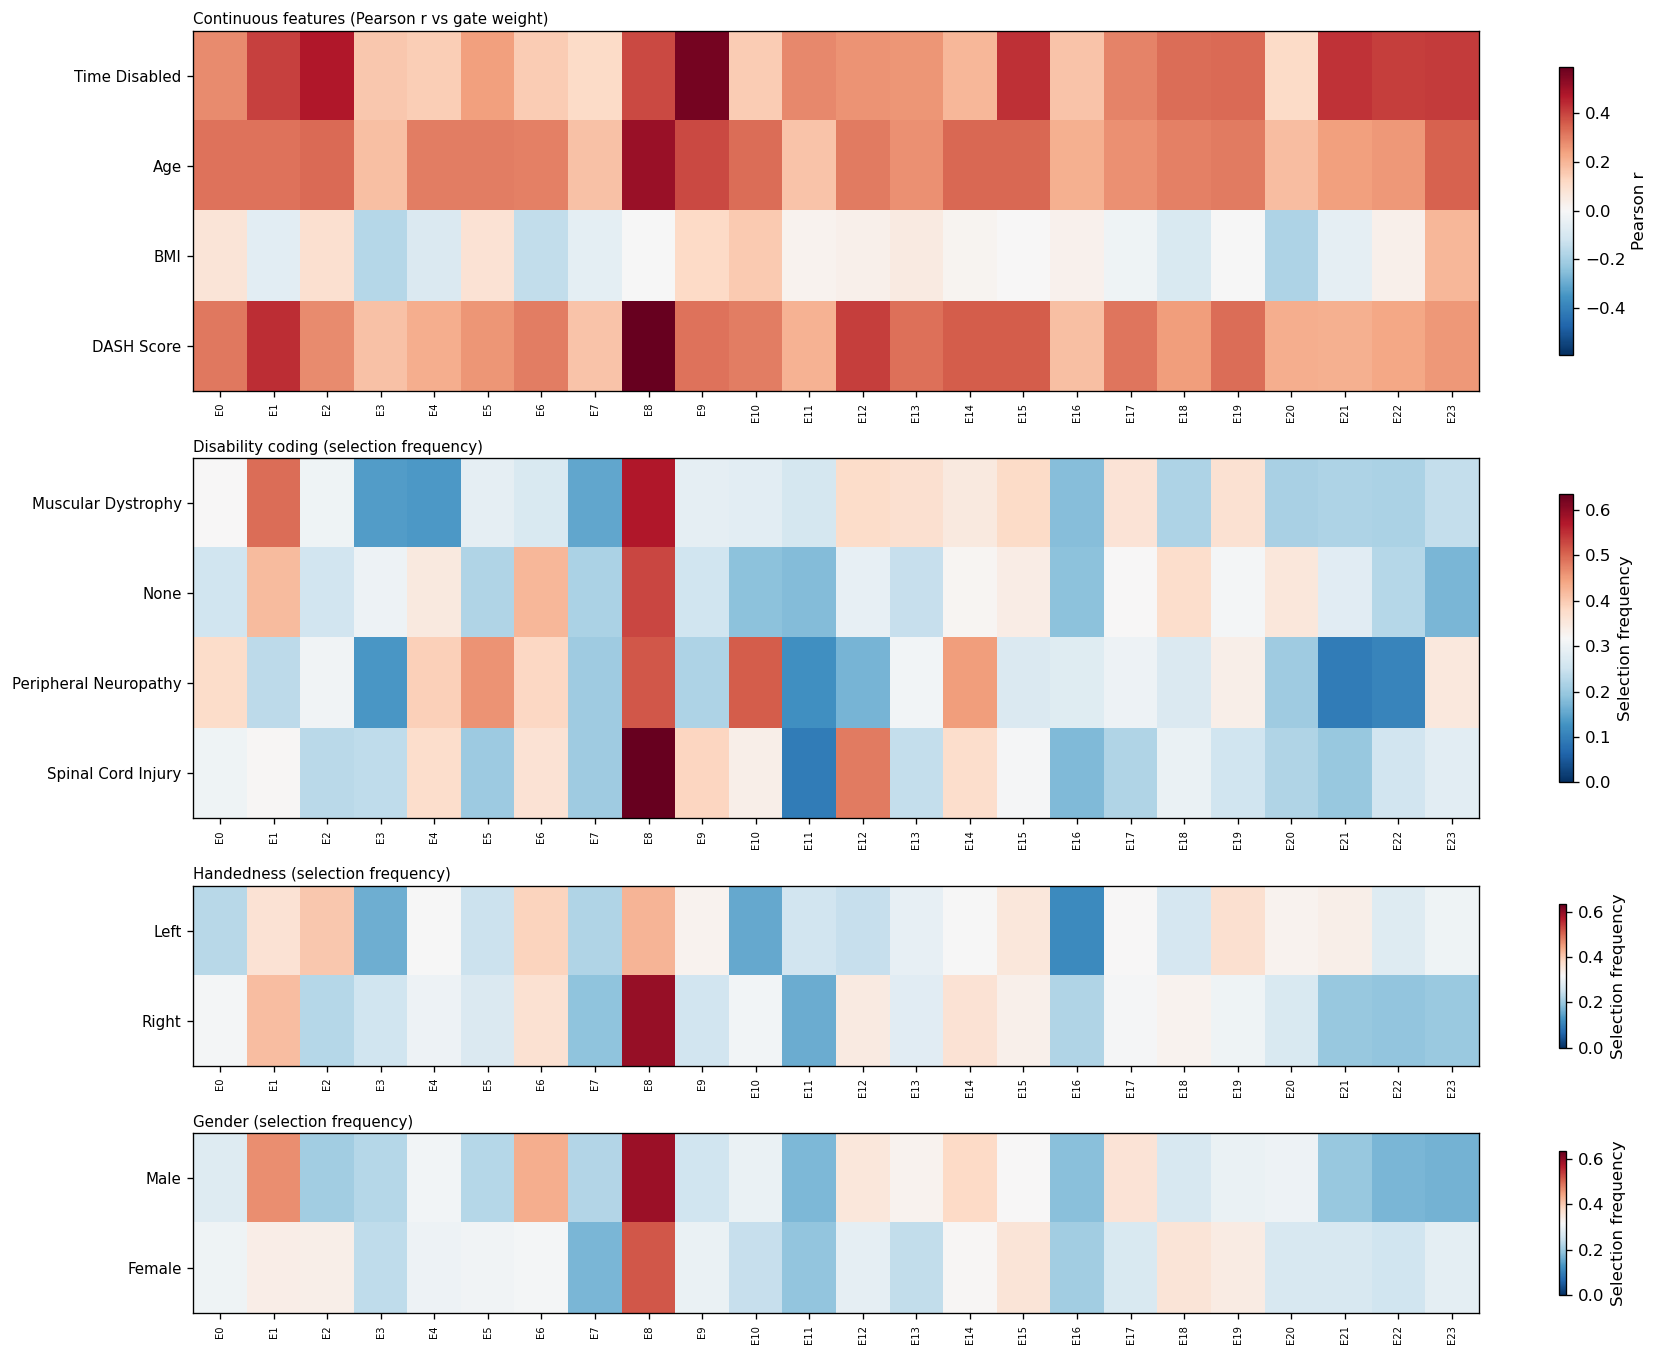


Continuous features (Pearson r vs gate weight):
  Time Disabled                       -> E02: +0.472
  Time Disabled                       -> E09: +0.564
  Age                                 -> E08: +0.513
  DASH Score                          -> E08: +0.592

Disability coding (selection frequency):
  Muscular Dystrophy                  -> E01: +0.494
  Muscular Dystrophy                  -> E08: +0.571
  None                                -> E08: +0.528
  Peripheral Neuropathy               -> E05: +0.460
  Peripheral Neuropathy               -> E08: +0.515
  Peripheral Neuropathy               -> E10: +0.510
  Peripheral Neuropathy               -> E14: +0.449
  Spinal Cord Injury                  -> E08: +0.634
  Spinal Cord Injury                  -> E12: +0.482

Handedness (selection frequency):
  Right                               -> E08: +0.592

Gender (selection frequency):
  Male                                -> E01: +0.465
  Male                                -> E08: +0

In [29]:
# ── 8d. Demographics × Expert correlation — grouped subpanels ─────────────────
#
# Continuous features: Pearson r between feature value and gate weight
# Categorical features: expert selection frequency per group
#   (fraction of samples in that category where each expert was in the top-k)
#
# "Selected" = gate_weight > 0, which is exactly the top-k active set.

if record.demographics is None:
    print("No demographics collected — check 'demo' key in query_batch.")
else:
    demo = record.demographics.float()   # (N, 12)
    gw   = record.gate_weights.float()   # (N, E)

    # Binary selection mask: was each expert chosen (top-k) for each sample?
    selected = (gw > 0).float()          # (N, E)  — 1 if in top-k, 0 otherwise

    # Sanity check: every row should have exactly top_k ones
    k_per_sample = selected.sum(dim=1)
    assert k_per_sample.min().item() == k_per_sample.max().item(), \
        f"Unexpected: top-k counts vary {k_per_sample.min()}-{k_per_sample.max()}"
    print(f"top-k confirmed: each sample selects {int(k_per_sample[0].item())} experts")

    # ── Reconstruct dropped reference columns ────────────────────────────────
    disability_cols = demo[:, 4:9]
    disability_ET   = 1.0 - disability_cols.sum(dim=1, keepdim=True)
    handedness_Left = 1.0 - demo[:, 9:10]
    gender_Man      = 1.0 - demo[:, 10:12].sum(dim=1, keepdim=True)

    demo_aug = torch.cat([
        demo[:, :4],                          # continuous
        disability_ET, demo[:, 4:9],          # disability (ET ref first)
        handedness_Left, demo[:, 9:10],       # handedness (Left ref first)
        gender_Man, demo[:, 10:12],           # gender (Man ref first)
    ], dim=1)   # (N, 15)

    #all_labels = [
    #    "time_disabled", "age", "BMI", "DASH_score",
    #    "disability_ET", "disability_MD", "disability_No_Disability",
    #    "disability_PN", "disability_SCI", "disability_other",
    #    "handedness_Left", "handedness_Right",
    #    "gender_Man", "gender_Non-binary", "gender_Woman",
    #]
    all_labels = [
        "Time Disabled", "Age", "BMI", "DASH Score",
        "Essential Tremors", "Muscular Dystrophy", "None", "Peripheral Neuropathy", "Spinal Cord Injury", "Other",
        "Left", "Right",
        "Male", "Non-binary", "Female",
    ]

    # ── Drop features absent from this user set ──────────────────────────────
    PRESENCE_THRESHOLD = 0.75
    keep_mask         = demo_aug.abs().sum(dim=0) > PRESENCE_THRESHOLD
    demo_filt         = demo_aug[:, keep_mask]
    labels_filt       = [l for l, k in zip(all_labels, keep_mask.tolist()) if k]
    is_continuous     = [l in ("time_disabled", "age", "BMI", "DASH_score")
                         for l in labels_filt]

    dropped = [l for l, k in zip(all_labels, keep_mask.tolist()) if not k]
    if dropped:
        print(f"Dropped absent features: {dropped}")
    print(f"Kept {len(labels_filt)} features: {labels_filt}")

    # ── Compute stat matrix (D_kept, E) ─────────────────────────────────────
    # Continuous rows → Pearson r(feature_value, gate_weight)
    # Categorical rows → selection frequency = mean(selected | group)
    D   = len(labels_filt)
    mat = np.zeros((D, E))

    for d_idx, (label, is_cont) in enumerate(zip(labels_filt, is_continuous)):
        col = demo_filt[:, d_idx]   # (N,)

        if is_cont:
            # Pearson r against gate weight (not selection — weight is more
            # meaningful for continuous features where selection is too coarse)
            col_np = col.numpy()
            for e in range(E):
                w = gw[:, e].numpy()
                if col_np.std() < 1e-8 or w.std() < 1e-8:
                    mat[d_idx, e] = 0.0
                else:
                    mat[d_idx, e] = float(np.corrcoef(col_np, w)[0, 1])
        else:
            # Selection frequency: fraction of THIS GROUP's samples that
            # selected expert e (i.e., had e in their top-k)
            mask = col > 0.5            # samples belonging to this category
            if mask.sum() == 0:
                mat[d_idx, :] = 0.0
            else:
                # mean over group samples of the binary selection indicator
                mat[d_idx, :] = selected[mask].mean(dim=0).numpy()

    # ── Build groups (only include rows that survived presence filter) ────────
    group_defs = [
        {"title": "Continuous features (Pearson r vs gate weight)",
         "labels": ["Time Disabled", "Age", "BMI", "DASH Score"]},
        {"title": "Disability coding (selection frequency)",
         "labels": ["Essential Tremors", "Muscular Dystrophy", "None", "Peripheral Neuropathy", "Spinal Cord Injury", "Other"]},
        {"title": "Handedness (selection frequency)",
         "labels": ["Left", "Right"]},
        {"title": "Gender (selection frequency)",
         "labels": ["Male", "Non-binary", "Female"]},
    ]

    groups = []
    for gdef in group_defs:
        rows = [(labels_filt.index(l), l)
                for l in gdef["labels"] if l in labels_filt]
        if rows:
            groups.append({"title": gdef["title"], "rows": rows})

    # ── Separate colormaps and scales per type ────────────────────────────────
    # Continuous: diverging, centred at 0, range = max |r|
    # Categorical: sequential from 0 to max selection freq
    #              with a reference line at k/E = 7/24 ≈ 0.29 (uniform baseline)
    cont_indices = [r[0] for g in groups[:1] for r in g["rows"]]
    cat_indices  = [r[0] for g in groups[1:] for r in g["rows"]]

    cont_vlim    = max(abs(mat[cont_indices]).max(), 0.05) if cont_indices else 0.3
    cat_vmax     = max(mat[cat_indices].max(),        0.05) if cat_indices  else 1.0
    uniform_freq = config['MOE_top_k'] / E   # 7/24 ≈ 0.292

    # ── Plot ─────────────────────────────────────────────────────────────────
    fig_w   = max(10, E * 0.55 + 2)
    heights = [max(2, len(g["rows"])) for g in groups]
    fig, axes = plt.subplots(
        len(groups), 1,
        figsize=(fig_w, sum(h * 0.55 + 1.2 for h in heights)),
        gridspec_kw={"height_ratios": heights},
    )
    if len(groups) == 1:
        axes = [axes]

    for ax, grp in zip(axes, groups):
        row_indices = [r[0] for r in grp["rows"]]
        row_labels  = [r[1] for r in grp["rows"]]
        sub_mat     = mat[row_indices, :]
        is_cont_grp = row_labels[0] in ("Time Disabled", "Age", "BMI", "DASH Score")

        if is_cont_grp:
            im = ax.imshow(sub_mat, aspect="auto",
                           vmin=-cont_vlim, vmax=cont_vlim, cmap="RdBu_r")
            cbar_label = "Pearson r"
        else:
            im = ax.imshow(sub_mat, aspect="auto",
                           vmin=0, vmax=cat_vmax, 
                           #cmap="YlOrRd")
                            cmap="RdBu_r")
            cbar_label = "Selection frequency"
            # Overlay the uniform baseline as a subtle contour
            #ax.contour(sub_mat, levels=[uniform_freq],
            #           colors=["steelblue"], linewidths=0.8, linestyles="--",
            #           alpha=0.6)
            # Label the baseline on the first categorical plot only
            #if grp == groups[1]:
            #    ax.plot([], [], color="steelblue", linewidth=0.8, linestyle="--",
            #            label=f"Uniform baseline ({uniform_freq:.2f})")
            #    ax.legend(fontsize=7, loc="upper right")

        ax.set_xticks(range(E))
        ax.set_xticklabels([f"E{i}" for i in range(E)], rotation=90, fontsize=6)
        ax.set_yticks(range(len(row_labels)))
        ax.set_yticklabels(row_labels, fontsize=9)
        ax.set_title(grp["title"], fontsize=9, loc="left", pad=4)
        plt.colorbar(im, ax=ax, label=cbar_label, shrink=0.8)

    n_users = len(set(record.pids))
    #fig.suptitle(
    #    f"Expert Specialisation by Demographics — {record.model_name}\n"
    #    f"N_users={n_users}  |  N_samples={len(record.pids)}  |  top_k={config['MOE_top_k']}/{E}\n"
    #    "Categorical: fraction of group's samples that selected each expert  |  "
    #    "⚠ N_eff = number of unique users",
    #    fontsize=8, y=1.01,
    #)
    fig.tight_layout()
    plt.show()

    # ── Print summary ────────────────────────────────────────────────────────
    THRESHOLD_CONT = 0.15
    THRESHOLD_CAT  = uniform_freq * 1.5   # 50% above uniform = noteworthy

    for grp in groups:
        print(f"\n{grp['title']}:")
        is_cont_grp = grp["rows"][0][1] in ("time_disabled", "age", "BMI", "DASH_score")
        thresh      = THRESHOLD_CONT if is_cont_grp else THRESHOLD_CAT
        found = False
        for row_idx, label in grp["rows"]:
            for e_idx in range(E):
                v = mat[row_idx, e_idx]
                if (is_cont_grp and abs(v) > thresh) or \
                   (not is_cont_grp and v > thresh):
                    marker = "r" if not is_cont_grp else ("+r" if v > 0 else "-r")
                    print(f"  {label:35s} -> E{e_idx:02d}: {v:+.3f}")
                    found = True
        if not found:
            print(f"  (nothing notable above threshold {thresh:.3f})")

Dropped absent features: ['Essential Tremors', 'Other', 'Non-binary']
Kept 12 features: ['Time Disabled', 'Age', 'BMI', 'DASH Score', 'Muscular Dystrophy', 'None', 'Peripheral Neuropathy', 'Spinal Cord Injury', 'Left', 'Right', 'Male', 'Female']


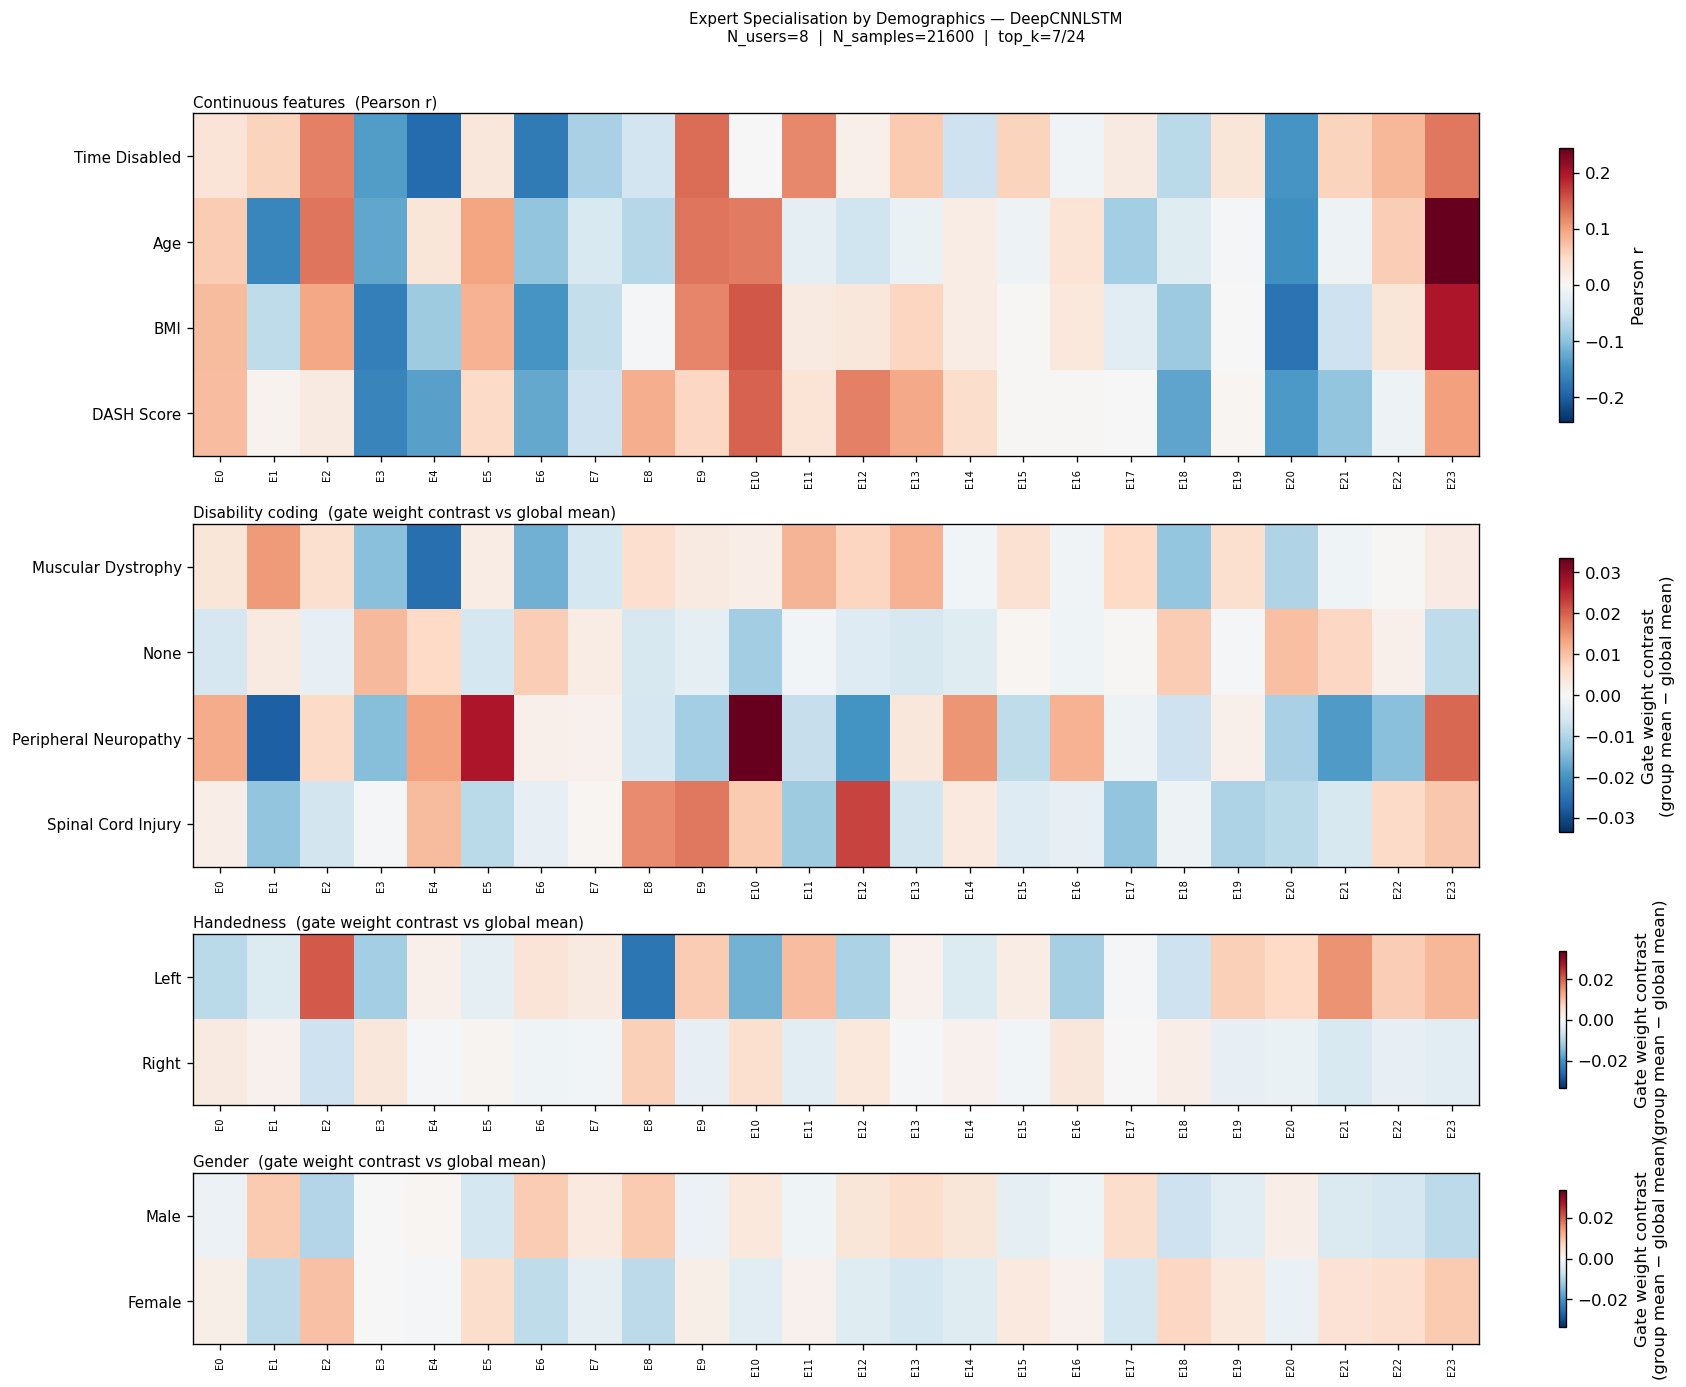


Continuous features  (Pearson r):
  Time Disabled                       -> E04: -0.1886
  Time Disabled                       -> E06: -0.1725
  Age                                 -> E01: -0.1594
  Age                                 -> E23: +0.2446
  BMI                                 -> E03: -0.1677
  BMI                                 -> E10: +0.1528
  BMI                                 -> E20: -0.1804
  BMI                                 -> E23: +0.1970
  DASH Score                          -> E03: -0.1622

Disability coding  (gate weight contrast vs global mean):
  Muscular Dystrophy                  -> E01: +0.0144
  Muscular Dystrophy                  -> E03: -0.0140
  Muscular Dystrophy                  -> E04: -0.0252
  Muscular Dystrophy                  -> E06: -0.0162
  Peripheral Neuropathy               -> E01: -0.0274
  Peripheral Neuropathy               -> E03: -0.0144
  Peripheral Neuropathy               -> E04: +0.0136
  Peripheral Neuropathy               -> E

In [27]:
# ── 8d. Demographics × Expert — gate weight contrast heatmap ─────────────────
#
# Continuous features : Pearson r(feature_value, gate_weight)
# Categorical features: mean gate weight for this group  MINUS
#                       mean gate weight across ALL samples
#
# The contrast removes the "some experts are just globally popular" baseline
# and isolates which experts are selectively preferred by each demographic group.
# Positive = this group routes more than average through this expert.
# Negative = this group routes less than average through this expert.

if record.demographics is None:
    print("No demographics collected — check 'demo' key in query_batch.")
else:
    demo = record.demographics.float()   # (N, 12)
    gw   = record.gate_weights.float()   # (N, E)

    # ── Reconstruct dropped reference columns ────────────────────────────────
    disability_cols = demo[:, 4:9]
    disability_ET   = 1.0 - disability_cols.sum(dim=1, keepdim=True)
    handedness_Left = 1.0 - demo[:, 9:10]
    gender_Man      = 1.0 - demo[:, 10:12].sum(dim=1, keepdim=True)

    demo_aug = torch.cat([
        demo[:, :4],
        disability_ET, demo[:, 4:9],
        handedness_Left, demo[:, 9:10],
        gender_Man, demo[:, 10:12],
    ], dim=1)   # (N, 15)

    #all_labels = [
    #    "time_disabled", "age", "BMI", "DASH_score",
    #    "disability_ET", "disability_MD", "disability_No_Disability",
    #    "disability_PN", "disability_SCI", "disability_other",
    #    "handedness_Left", "handedness_Right",
    #    "gender_Man", "gender_Non-binary", "gender_Woman",
    #]
    all_labels = [
        "Time Disabled", "Age", "BMI", "DASH Score",
        "Essential Tremors", "Muscular Dystrophy", "None", "Peripheral Neuropathy", "Spinal Cord Injury", "Other",
        "Left", "Right",
        "Male", "Non-binary", "Female",
    ]
    continuous_labels = {"Time Disabled", "Age", "BMI", "DASH Score"}

    # ── Drop absent features ─────────────────────────────────────────────────
    PRESENCE_THRESHOLD = 0.75
    keep_mask   = demo_aug.abs().sum(dim=0) > PRESENCE_THRESHOLD
    demo_filt   = demo_aug[:, keep_mask]
    labels_filt = [l for l, k in zip(all_labels, keep_mask.tolist()) if k]
    dropped     = [l for l, k in zip(all_labels, keep_mask.tolist()) if not k]
    if dropped:
        print(f"Dropped absent features: {dropped}")
    print(f"Kept {len(labels_filt)} features: {labels_filt}")

    # ── Global mean gate weight per expert (the baseline) ───────────────────
    global_mean = gw.mean(dim=0).numpy()   # (E,)

    # ── Compute stat matrix (D_kept, E) ─────────────────────────────────────
    D   = len(labels_filt)
    mat = np.zeros((D, E))

    for d_idx, label in enumerate(labels_filt):
        col = demo_filt[:, d_idx]   # (N,)

        if label in continuous_labels:
            # Pearson r between feature value and gate weight
            col_np = col.numpy()
            for e in range(E):
                w = gw[:, e].numpy()
                if col_np.std() < 1e-8 or w.std() < 1e-8:
                    mat[d_idx, e] = 0.0
                else:
                    mat[d_idx, e] = float(np.corrcoef(col_np, w)[0, 1])
        else:
            # Gate weight contrast: group mean minus global mean
            mask = col > 0.5
            if mask.sum() == 0:
                mat[d_idx, :] = 0.0
            else:
                group_mean     = gw[mask].mean(dim=0).numpy()   # (E,)
                mat[d_idx, :]  = group_mean - global_mean

    # ── Group definitions ────────────────────────────────────────────────────
    group_defs = [
        {"title": "Continuous features  (Pearson r)",
         "labels": ["Time Disabled", "Age", "BMI", "DASH Score"]},
        {"title": "Disability coding  (gate weight contrast vs global mean)",
         "labels": ["Essential Tremors", "Muscular Dystrophy", "None", "Peripheral Neuropathy", "Spinal Cord Injury", "Other"]},
        {"title": "Handedness  (gate weight contrast vs global mean)",
         "labels": ["Left", "Right"]},
        {"title": "Gender  (gate weight contrast vs global mean)",
         "labels": ["Male", "Non-binary", "Female"]},
    ]

    groups = []
    for gdef in group_defs:
        rows = [(labels_filt.index(l), l)
                for l in gdef["labels"] if l in labels_filt]
        if rows:
            groups.append({"title": gdef["title"], "rows": rows})

    # ── Shared colorbar scale across categorical groups ──────────────────────
    # Continuous keeps its own scale (Pearson r, different units).
    # All categorical subplots share one vlim so colors are comparable.
    cont_rows = [r[0] for g in groups if "Pearson" in g["title"] for r in g["rows"]]
    cat_rows  = [r[0] for g in groups if "Pearson" not in g["title"] for r in g["rows"]]
    cont_vlim = max(abs(mat[cont_rows]).max(), 0.05) if cont_rows else 0.3
    cat_vlim  = max(abs(mat[cat_rows]).max(),  0.005) if cat_rows  else 0.05

    # ── Plot ─────────────────────────────────────────────────────────────────
    fig_w   = max(10, E * 0.55 + 2)
    heights = [max(2, len(g["rows"])) for g in groups]
    fig, axes = plt.subplots(
        len(groups), 1,
        figsize=(fig_w, sum(h * 0.55 + 1.2 for h in heights)),
        gridspec_kw={"height_ratios": heights},
    )
    if len(groups) == 1:
        axes = [axes]

    for ax, grp in zip(axes, groups):
        row_indices = [r[0] for r in grp["rows"]]
        row_labels  = [r[1] for r in grp["rows"]]
        sub_mat     = mat[row_indices, :]
        is_cont_grp = "Pearson" in grp["title"]

        vlim      = cont_vlim if is_cont_grp else cat_vlim
        cbar_label = "Pearson r" if is_cont_grp else "Gate weight contrast\n(group mean − global mean)"

        im = ax.imshow(sub_mat, aspect="auto",
                       vmin=-vlim, vmax=vlim, cmap="RdBu_r")
        ax.set_xticks(range(E))
        ax.set_xticklabels([f"E{i}" for i in range(E)], rotation=90, fontsize=6)
        ax.set_yticks(range(len(row_labels)))
        ax.set_yticklabels(row_labels, fontsize=9)
        ax.set_title(grp["title"], fontsize=9, loc="left", pad=4)
        plt.colorbar(im, ax=ax, label=cbar_label, shrink=0.8)

    n_users = len(set(record.pids))
    fig.suptitle(
        f"Expert Specialisation by Demographics — {record.model_name}\n"
        f"N_users={n_users}  |  N_samples={len(record.pids)}  |  top_k={config['MOE_top_k']}/{E}",
        fontsize=9, y=1.01,
    )
    fig.tight_layout()
    plt.show()

    # ── Print notable contrasts ──────────────────────────────────────────────
    THRESHOLD_CONT = 0.15
    THRESHOLD_CAT  = cat_vlim * 0.4   # top 40% of observed range

    for grp in groups:
        print(f"\n{grp['title']}:")
        is_cont_grp = "Pearson" in grp["title"]
        thresh = THRESHOLD_CONT if is_cont_grp else THRESHOLD_CAT
        found  = False
        for row_idx, label in grp["rows"]:
            for e_idx in range(E):
                v = mat[row_idx, e_idx]
                if abs(v) > thresh:
                    print(f"  {label:35s} -> E{e_idx:02d}: {v:+.4f}")
                    found = True
        if not found:
            print(f"  (nothing above threshold {thresh:.4f})")

### 8e. Per-sample routing entropy histogram
- Entropy = 0 nats: all weight on one expert (perfectly hard)
- Entropy = log(7) = 1.95 nats: uniform over the 7 active experts (top-k maximum)
- Entropy = log(24) = 3.18 nats: uniform over all experts (would mean gate is ignoring top-k)

Values well below log(7) indicate the gate is making sharp decisions within its active set.

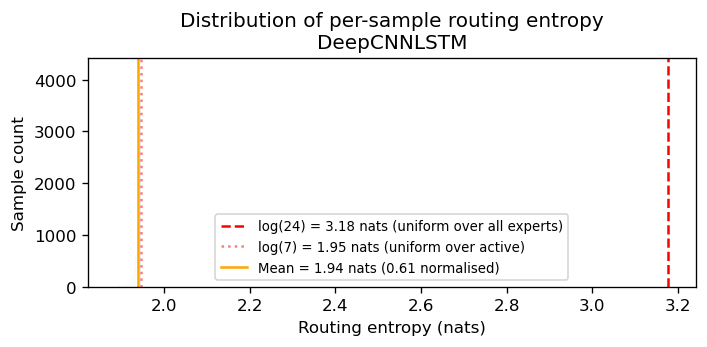

Mean entropy (normalised 0=sharp, 1=flat): 0.6102


In [14]:
ent_stats = analyzer.routing_entropy()

w         = record.gate_weights.clamp(min=1e-9)
h         = -(w * w.log()).sum(dim=-1).numpy()
max_h     = math.log(E)
topk_max_h = math.log(config['MOE_top_k'])

fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(h, bins=40, color='#4C72B0', edgecolor='white', alpha=0.85)
ax.axvline(max_h, color='red', linestyle='--',
           label=f'log({E}) = {max_h:.2f} nats (uniform over all experts)')
ax.axvline(topk_max_h, color='salmon', linestyle=':',
           label=f'log({config["MOE_top_k"]}) = {topk_max_h:.2f} nats (uniform over active)')
ax.axvline(ent_stats['mean_entropy_nats'], color='orange', linestyle='-',
           label=f"Mean = {ent_stats['mean_entropy_nats']:.2f} nats ({ent_stats['mean_entropy_normalised']:.2f} normalised)")
ax.set_xlabel('Routing entropy (nats)')
ax.set_ylabel('Sample count')
ax.set_title(f'Distribution of per-sample routing entropy\n{record.model_name}')
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

print(f"Mean entropy (normalised 0=sharp, 1=flat): {ent_stats['mean_entropy_normalised']:.4f}")

### 8f. Expert co-activation matrix
Pearson r between pairs of expert gate weights across all samples.
- Strong **negative** off-diagonal: experts anti-correlate = specialised, mutually exclusive
- Strong **positive** off-diagonal: experts tend to fire together = potentially redundant

With E=24 look for block structure — groups of correlated experts may indicate clusters.

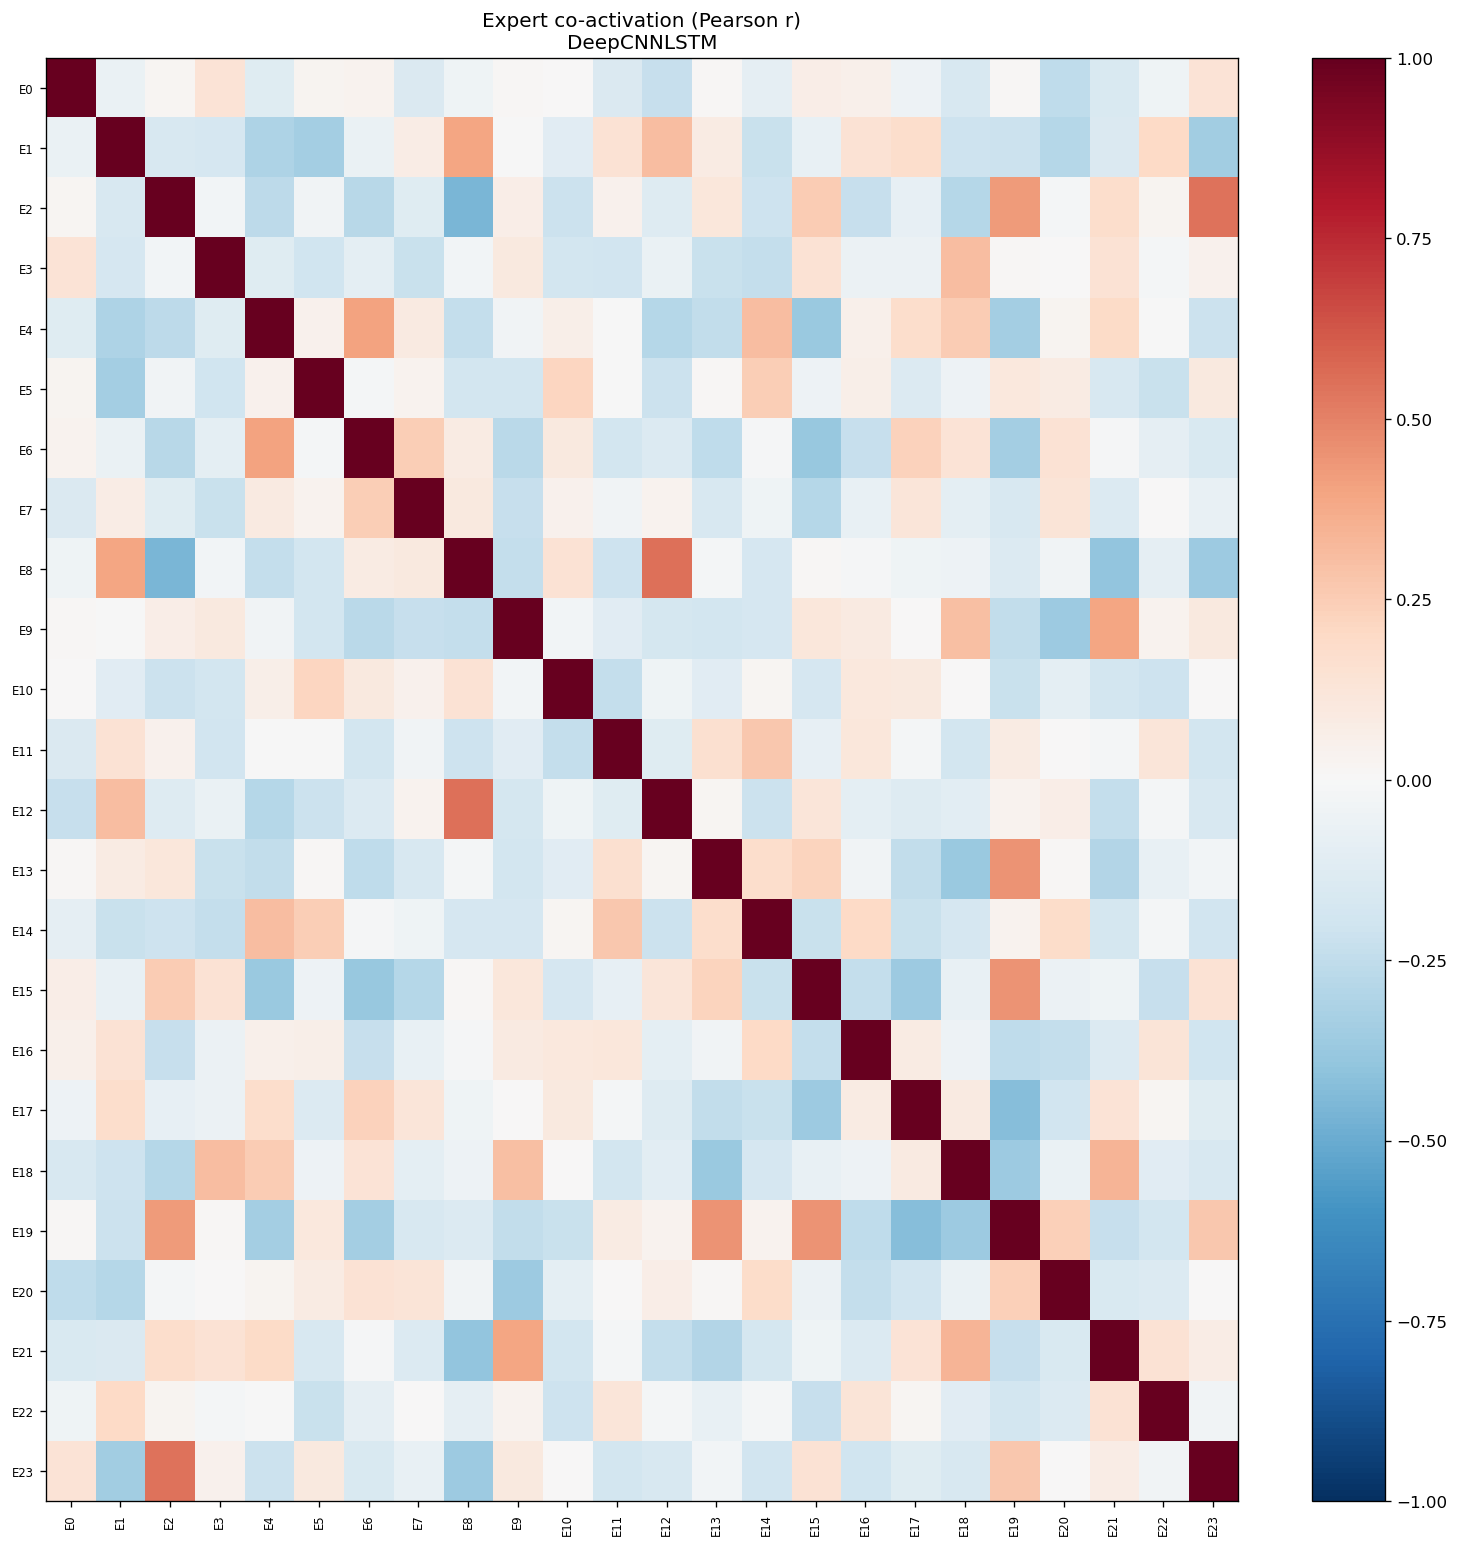

In [15]:
ca  = analyzer.expert_coactivation()
mat = np.array(ca['coactivation_matrix'])  # (E, E)

fig, ax = plt.subplots(figsize=(max(8, E * 0.5 + 1), max(8, E * 0.5 + 1)))
im = ax.imshow(mat, aspect='auto', vmin=-1, vmax=1, cmap='RdBu_r')
ax.set_xticks(range(E))
ax.set_xticklabels([f'E{i}' for i in range(E)], rotation=90, fontsize=7)
ax.set_yticks(range(E))
ax.set_yticklabels([f'E{i}' for i in range(E)], fontsize=7)
ax.set_title(f'Expert co-activation (Pearson r)\n{record.model_name}')
plt.colorbar(im, ax=ax)
fig.tight_layout()
plt.show()

## 9. Save the RoutingRecord

Strongly recommended: save now so you can reload and re-run any figure cell
without re-running the full (slow) val collection loop.

In [16]:
from MOE.MOE_analysis import save_routing_record, load_routing_record

# DUMMY_VARIABLE: where to save
RECORD_SAVE_PATH = "/DUMMY/path/to/routing_record.pt"

# Uncomment to save:
# save_routing_record(record, RECORD_SAVE_PATH)
# print(f'Saved to {RECORD_SAVE_PATH}')

# To reload and skip cells 3-6 on future runs:
# record   = load_routing_record(RECORD_SAVE_PATH)
# analyzer = RoutingAnalyzer(record)
# E        = analyzer.E
# print(f'Loaded {record.gate_weights.shape[0]} samples')